# MRT1 histogram (journal-style)

Run the **global aesthetics** cell once per session (after imports), then the plot cell. Per-histogram: bins, labels. Colorbar: **NRMSE (%)** = `J_m × 100`, limits **3%–4%**.


In [29]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


In [30]:
repo_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ensemble_csv = repo_root / 'two_components/outputs/phase_exploration/exploration_ensemble.csv'
if not ensemble_csv.exists():
    ensemble_csv = repo_root / 'two_components_/outputs/phase_exploration/exploration_ensemble.csv'

ensemble = pd.read_csv(ensemble_csv)
ensemble[['best_MRT1', 'J_m']].head()


,best_MRT1,J_m
0,11.499208,0.032658
1,11.594517,0.034102
2,11.543427,0.033832
3,11.578372,0.032566
4,11.693850,0.034437


## Global aesthetics (all histograms)

**Why not `with plt.rc_context(...)`?** `rc_context` only changes settings inside the `with` block, then restores them—useful when you mix different styles in one notebook.

**Here:** one cell calls `plt.rcParams.update(JOURNAL_RC)` so every figure you make **after** this cell uses the same journal defaults, without wrapping each plot in `with`. Re-run this cell if you change the dict; restart the kernel if figures look wrong after heavy experimentation.


In [31]:
# Line weights / grid (PublicationFigureQuality-style)
_pt = 1.0
_pt_hair = 0.5
font_size = 11
_grid_gray = "#F2F2F2"

JOURNAL_RC = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": font_size,
    "axes.labelsize": font_size,
    "xtick.labelsize": font_size,
    "ytick.labelsize": font_size,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.direction": "out",
    "ytick.direction": "out",
    "pdf.fonttype": 42,
}

plt.rcParams.update(JOURNAL_RC)


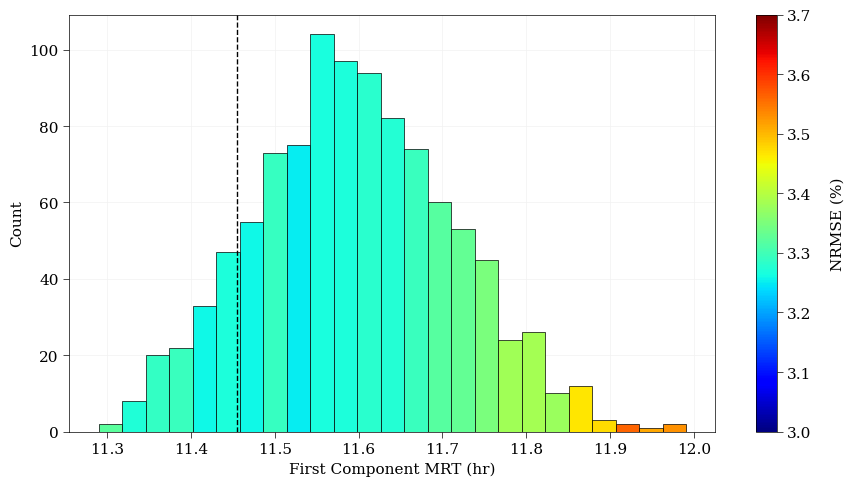

In [32]:
# MRT1 only — per-histogram options
column = "best_MRT1"
bins = 25
xlabel = "First Component MRT (hr)"
ylabel = "Count"

values = ensemble[column].to_numpy()
j_vals = ensemble["J_m"].to_numpy()
best_mrt1 = float(ensemble.loc[ensemble["J_m"].idxmin(), column])

counts, edges = np.histogram(values, bins=bins)
bin_ids = np.digitize(values, edges) - 1
bin_ids = np.clip(bin_ids, 0, len(edges) - 2)

bin_medians = np.full(len(edges) - 1, np.nan)
for i in range(len(bin_medians)):
    mask = bin_ids == i
    if np.any(mask):
        bin_medians[i] = np.median(j_vals[mask])

cmap = plt.cm.jet
nrmse_pct = bin_medians * 100.0
nrmse_norm = mpl.colors.Normalize(vmin=3.0, vmax=3.7)
# nrmse_norm = mpl.colors.Normalize(vmin=3.0, vmax=4)
colors = [
    cmap(nrmse_norm(v)) if not np.isnan(v) else (0.85, 0.85, 0.85, 1.0)
    for v in nrmse_pct
]

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.set_facecolor("white")

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.bar(
    edges[:-1],
    counts,
    width=np.diff(edges),
    align="edge",
    color=colors,
    edgecolor="black",
    linewidth=_pt_hair,
)
ax.axvline(best_mrt1, color="black", linestyle="--", linewidth=_pt, zorder=6)

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

sm = mpl.cm.ScalarMappable(norm=nrmse_norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("NRMSE (%)", labelpad=14)
cbar.ax.tick_params(width=_pt_hair, length=4)
cbar.outline.set_linewidth(_pt_hair)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

plt.show()


## MRT2 histogram
Count histogram for `best_MRT2` colored by median NRMSE (%) per bin.


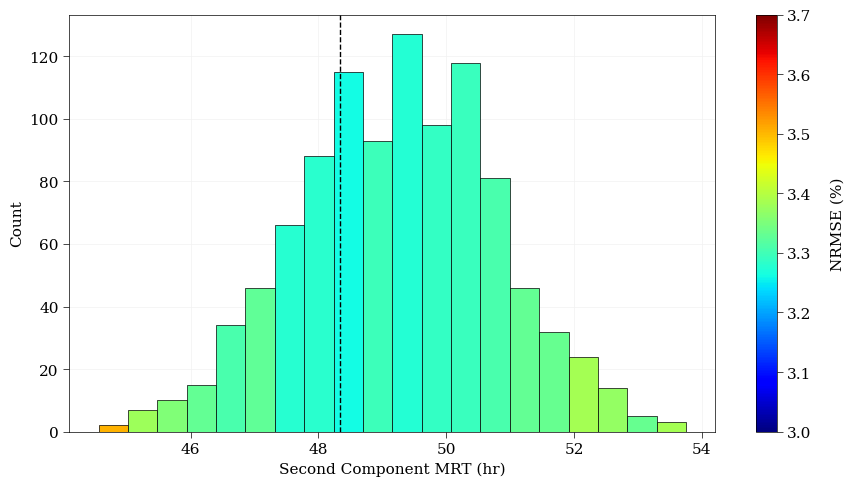

In [33]:
# best_MRT2 histogram
column = "best_MRT2"
bins = 20
xlabel = "Second Component MRT (hr)"
ylabel = "Count"

values = ensemble[column].to_numpy()
j_vals = ensemble["J_m"].to_numpy()
best_val = float(ensemble.loc[ensemble["J_m"].idxmin(), "best_MRT2"])

counts, edges = np.histogram(values, bins=bins)
bin_ids = np.digitize(values, edges) - 1
bin_ids = np.clip(bin_ids, 0, len(edges) - 2)

bin_medians = np.full(len(edges) - 1, np.nan)
for i in range(len(bin_medians)):
    mask = bin_ids == i
    if np.any(mask):
        bin_medians[i] = np.median(j_vals[mask])

cmap = plt.cm.jet
nrmse_pct = bin_medians * 100.0
nrmse_norm = mpl.colors.Normalize(vmin=3.0, vmax=3.7)
colors = [
    cmap(nrmse_norm(v)) if not np.isnan(v) else (0.85, 0.85, 0.85, 1.0)
    for v in nrmse_pct
]

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.bar(
    edges[:-1],
    counts,
    width=np.diff(edges),
    align="edge",
    color=colors,
    edgecolor="black",
    linewidth=_pt_hair,
)
ax.axvline(best_val, color="black", linestyle="--", linewidth=_pt, zorder=6)

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

sm = mpl.cm.ScalarMappable(norm=nrmse_norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("NRMSE (%)", labelpad=14)
cbar.ax.tick_params(width=_pt_hair, length=4)
cbar.outline.set_linewidth(_pt_hair)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

# Uncomment to save as PDF
# fig.savefig(
#     "mrt2_histogram.pdf",
#     facecolor="white",
#     edgecolor="none",
#     bbox_inches="tight",
#     pad_inches=0.25,
# )

plt.show()



## Pe1 histogram
Count histogram for `best_Pe1` colored by median NRMSE (%) per bin.


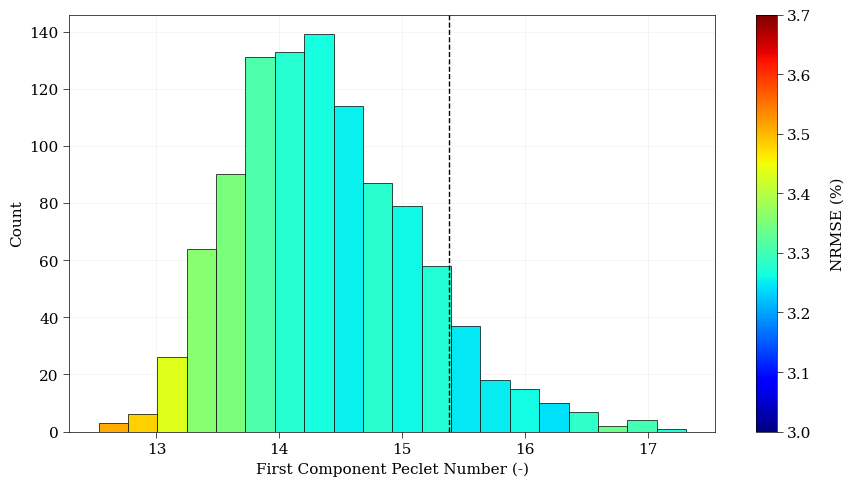

In [34]:
# best_Pe1 histogram
column = "best_Pe1"
bins = 20
xlabel = "First Component Peclet Number (-)"
ylabel = "Count"

values = ensemble[column].to_numpy()
j_vals = ensemble["J_m"].to_numpy()
best_val = float(ensemble.loc[ensemble["J_m"].idxmin(), "best_Pe1"])

counts, edges = np.histogram(values, bins=bins)
bin_ids = np.digitize(values, edges) - 1
bin_ids = np.clip(bin_ids, 0, len(edges) - 2)

bin_medians = np.full(len(edges) - 1, np.nan)
for i in range(len(bin_medians)):
    mask = bin_ids == i
    if np.any(mask):
        bin_medians[i] = np.median(j_vals[mask])

cmap = plt.cm.jet
nrmse_pct = bin_medians * 100.0
nrmse_norm = mpl.colors.Normalize(vmin=3.0, vmax=3.7)
colors = [
    cmap(nrmse_norm(v)) if not np.isnan(v) else (0.85, 0.85, 0.85, 1.0)
    for v in nrmse_pct
]

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.bar(
    edges[:-1],
    counts,
    width=np.diff(edges),
    align="edge",
    color=colors,
    edgecolor="black",
    linewidth=_pt_hair,
)
ax.axvline(best_val, color="black", linestyle="--", linewidth=_pt, zorder=6)

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

sm = mpl.cm.ScalarMappable(norm=nrmse_norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("NRMSE (%)", labelpad=14)
cbar.ax.tick_params(width=_pt_hair, length=4)
cbar.outline.set_linewidth(_pt_hair)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

# Uncomment to save as PDF
# fig.savefig(
#     "pe1_histogram.pdf",
#     facecolor="white",
#     edgecolor="none",
#     bbox_inches="tight",
#     pad_inches=0.25,
# )

plt.show()



## Pe2 histogram
Count histogram for `best_Pe2` colored by median NRMSE (%) per bin.


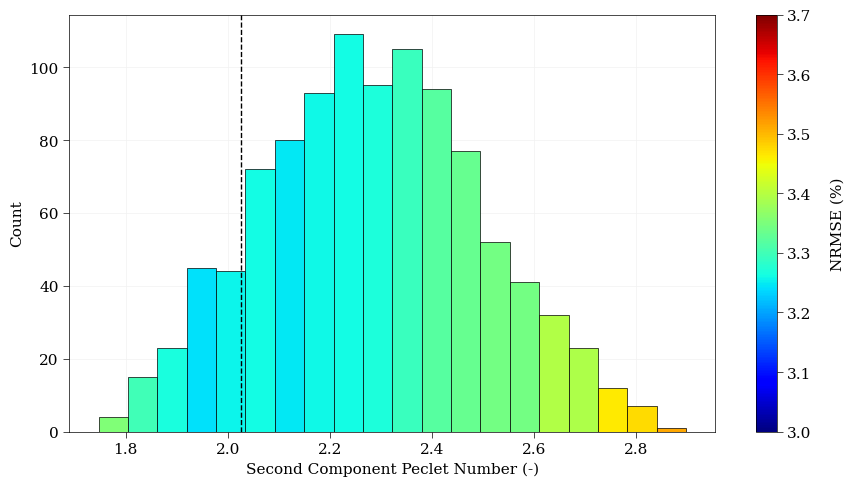

In [35]:
# best_Pe2 histogram
column = "best_Pe2"
bins = 20
xlabel = "Second Component Peclet Number (-)"
ylabel = "Count"

values = ensemble[column].to_numpy()
j_vals = ensemble["J_m"].to_numpy()
best_val = float(ensemble.loc[ensemble["J_m"].idxmin(), "best_Pe2"])

counts, edges = np.histogram(values, bins=bins)
bin_ids = np.digitize(values, edges) - 1
bin_ids = np.clip(bin_ids, 0, len(edges) - 2)

bin_medians = np.full(len(edges) - 1, np.nan)
for i in range(len(bin_medians)):
    mask = bin_ids == i
    if np.any(mask):
        bin_medians[i] = np.median(j_vals[mask])

cmap = plt.cm.jet
nrmse_pct = bin_medians * 100.0
nrmse_norm = mpl.colors.Normalize(vmin=3.0, vmax=3.7)
colors = [
    cmap(nrmse_norm(v)) if not np.isnan(v) else (0.85, 0.85, 0.85, 1.0)
    for v in nrmse_pct
]

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.bar(
    edges[:-1],
    counts,
    width=np.diff(edges),
    align="edge",
    color=colors,
    edgecolor="black",
    linewidth=_pt_hair,
)
ax.axvline(best_val, color="black", linestyle="--", linewidth=_pt, zorder=6)

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

sm = mpl.cm.ScalarMappable(norm=nrmse_norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("NRMSE (%)", labelpad=14)
cbar.ax.tick_params(width=_pt_hair, length=4)
cbar.outline.set_linewidth(_pt_hair)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

# Uncomment to save as PDF
# fig.savefig(
#     "pe2_histogram.pdf",
#     facecolor="white",
#     edgecolor="none",
#     bbox_inches="tight",
#     pad_inches=0.25,
# )

plt.show()



## fr1 histogram
Count histogram for `best_fr1` colored by median NRMSE (%) per bin.


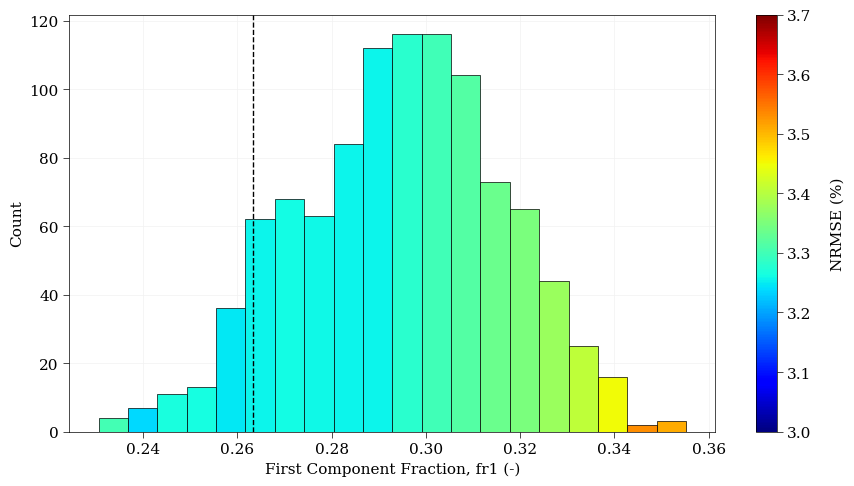

In [36]:
# best_fr1 histogram
column = "best_fr1"
bins = 20
xlabel = "First Component Fraction, fr1 (-)"
ylabel = "Count"

values = ensemble[column].to_numpy()
j_vals = ensemble["J_m"].to_numpy()
best_val = float(ensemble.loc[ensemble["J_m"].idxmin(), "best_fr1"])

counts, edges = np.histogram(values, bins=bins)
bin_ids = np.digitize(values, edges) - 1
bin_ids = np.clip(bin_ids, 0, len(edges) - 2)

bin_medians = np.full(len(edges) - 1, np.nan)
for i in range(len(bin_medians)):
    mask = bin_ids == i
    if np.any(mask):
        bin_medians[i] = np.median(j_vals[mask])

cmap = plt.cm.jet
nrmse_pct = bin_medians * 100.0
nrmse_norm = mpl.colors.Normalize(vmin=3.0, vmax=3.7)
colors = [
    cmap(nrmse_norm(v)) if not np.isnan(v) else (0.85, 0.85, 0.85, 1.0)
    for v in nrmse_pct
]

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.bar(
    edges[:-1],
    counts,
    width=np.diff(edges),
    align="edge",
    color=colors,
    edgecolor="black",
    linewidth=_pt_hair,
)
ax.axvline(best_val, color="black", linestyle="--", linewidth=_pt, zorder=6)

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

sm = mpl.cm.ScalarMappable(norm=nrmse_norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("NRMSE (%)", labelpad=14)
cbar.ax.tick_params(width=_pt_hair, length=4)
cbar.outline.set_linewidth(_pt_hair)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

# Uncomment to save as PDF
# fig.savefig(
#     "fr1_histogram.pdf",
#     facecolor="white",
#     edgecolor="none",
#     bbox_inches="tight",
#     pad_inches=0.25,
# )

plt.show()



## fr2 histogram
Count histogram for `best_fr2` colored by median NRMSE (%) per bin.


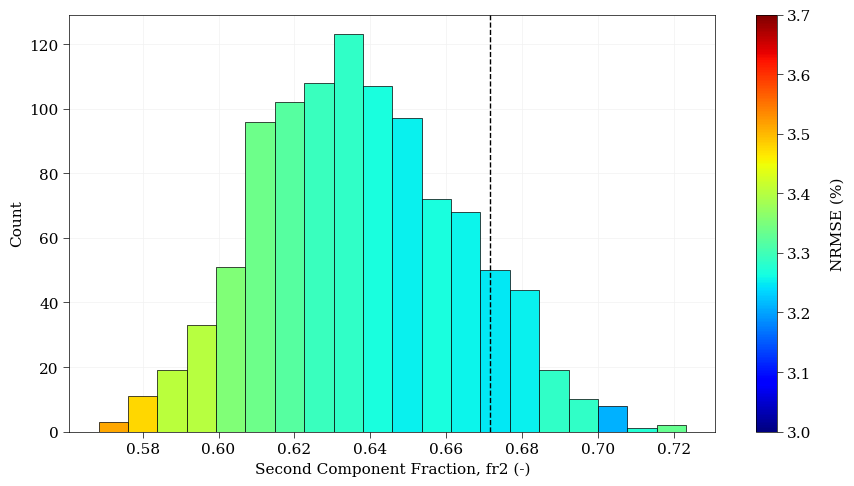

In [37]:
# best_fr2 histogram
column = "best_fr2"
bins = 20
xlabel = "Second Component Fraction, fr2 (-)"
ylabel = "Count"

values = ensemble[column].to_numpy()
j_vals = ensemble["J_m"].to_numpy()
best_val = float(ensemble.loc[ensemble["J_m"].idxmin(), "best_fr2"])

counts, edges = np.histogram(values, bins=bins)
bin_ids = np.digitize(values, edges) - 1
bin_ids = np.clip(bin_ids, 0, len(edges) - 2)

bin_medians = np.full(len(edges) - 1, np.nan)
for i in range(len(bin_medians)):
    mask = bin_ids == i
    if np.any(mask):
        bin_medians[i] = np.median(j_vals[mask])

cmap = plt.cm.jet
nrmse_pct = bin_medians * 100.0
nrmse_norm = mpl.colors.Normalize(vmin=3.0, vmax=3.7)
colors = [
    cmap(nrmse_norm(v)) if not np.isnan(v) else (0.85, 0.85, 0.85, 1.0)
    for v in nrmse_pct
]

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.bar(
    edges[:-1],
    counts,
    width=np.diff(edges),
    align="edge",
    color=colors,
    edgecolor="black",
    linewidth=_pt_hair,
)
ax.axvline(best_val, color="black", linestyle="--", linewidth=_pt, zorder=6)

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

sm = mpl.cm.ScalarMappable(norm=nrmse_norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("NRMSE (%)", labelpad=14)
cbar.ax.tick_params(width=_pt_hair, length=4)
cbar.outline.set_linewidth(_pt_hair)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

# Uncomment to save as PDF
# fig.savefig(
#     "fr2_histogram.pdf",
#     facecolor="white",
#     edgecolor="none",
#     bbox_inches="tight",
#     pad_inches=0.25,
# )

plt.show()



## R histogram
Count histogram for `R = fr1 + fr2` colored by median NRMSE (%) per bin.


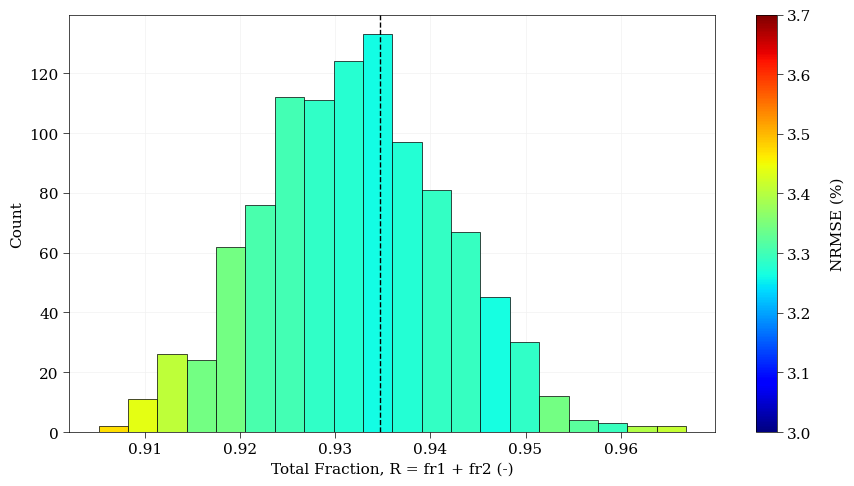

In [38]:
# R histogram (R = fr1 + fr2)
bins = 20
xlabel = "Total Fraction, R = fr1 + fr2 (-)"
ylabel = "Count"

R_vals = ensemble["best_fr1"].to_numpy() + ensemble["best_fr2"].to_numpy()
j_vals = ensemble["J_m"].to_numpy()
best_idx = ensemble["J_m"].idxmin()
best_val = float(ensemble.loc[best_idx, "best_fr1"] + ensemble.loc[best_idx, "best_fr2"])

counts, edges = np.histogram(R_vals, bins=bins)
bin_ids = np.digitize(R_vals, edges) - 1
bin_ids = np.clip(bin_ids, 0, len(edges) - 2)

bin_medians = np.full(len(edges) - 1, np.nan)
for i in range(len(bin_medians)):
    mask = bin_ids == i
    if np.any(mask):
        bin_medians[i] = np.median(j_vals[mask])

cmap = plt.cm.jet
nrmse_pct = bin_medians * 100.0
nrmse_norm = mpl.colors.Normalize(vmin=3.0, vmax=3.7)
colors = [
    cmap(nrmse_norm(v)) if not np.isnan(v) else (0.85, 0.85, 0.85, 1.0)
    for v in nrmse_pct
]

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.bar(edges[:-1], counts, width=np.diff(edges), align="edge", color=colors, edgecolor="black", linewidth=_pt_hair)
ax.axvline(best_val, color="black", linestyle="--", linewidth=_pt, zorder=6)

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(axis="both", which="major", direction="out", length=4, width=_pt_hair, colors="black", top=False, right=False)

sm = mpl.cm.ScalarMappable(norm=nrmse_norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("NRMSE (%)", labelpad=14)
cbar.ax.tick_params(width=_pt_hair, length=4)
cbar.outline.set_linewidth(_pt_hair)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

# Uncomment to save as PDF
# fig.savefig(
#     "R_histogram.pdf",
#     facecolor="white",
#     edgecolor="none",
#     bbox_inches="tight",
#     pad_inches=0.25,
# )

plt.show()



## f1 histogram
Count histogram for `f1 = fr1 / R` colored by median NRMSE (%) per bin.


## f2 histogram
Count histogram for `f2 = fr2 / R` colored by median NRMSE (%) per bin.


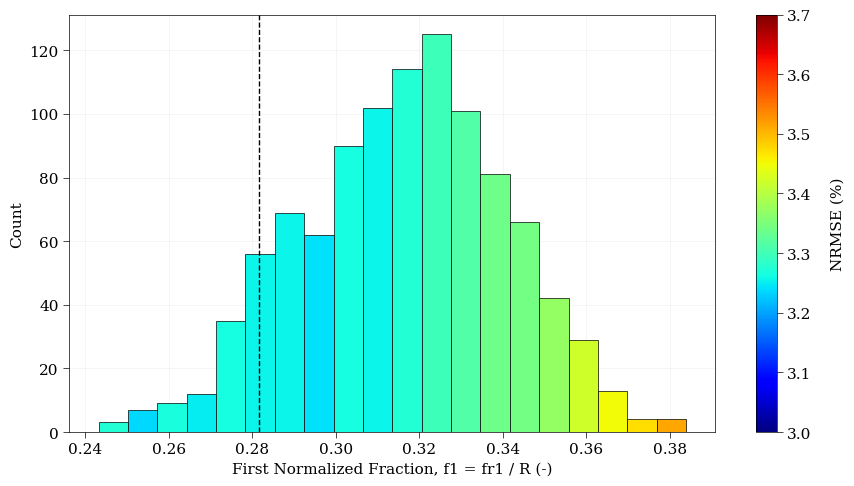

In [39]:
# f1 histogram (f1 = fr1 / R)
bins = 20
xlabel = "First Normalized Fraction, f1 = fr1 / R (-)"
ylabel = "Count"

fr1 = ensemble["best_fr1"].to_numpy()
fr2 = ensemble["best_fr2"].to_numpy()
R_vals = fr1 + fr2
f1_vals = np.where(R_vals > 0, fr1 / R_vals, np.nan)
j_vals = ensemble["J_m"].to_numpy()

best_idx = ensemble["J_m"].idxmin()
best_R = float(ensemble.loc[best_idx, "best_fr1"] + ensemble.loc[best_idx, "best_fr2"])
best_val = float(ensemble.loc[best_idx, "best_fr1"] / best_R) if best_R > 0 else np.nan

mask_valid = np.isfinite(f1_vals)
vals = f1_vals[mask_valid]
j_use = j_vals[mask_valid]

counts, edges = np.histogram(vals, bins=bins)
bin_ids = np.digitize(vals, edges) - 1
bin_ids = np.clip(bin_ids, 0, len(edges) - 2)

bin_medians = np.full(len(edges) - 1, np.nan)
for i in range(len(bin_medians)):
    mask = bin_ids == i
    if np.any(mask):
        bin_medians[i] = np.median(j_use[mask])

cmap = plt.cm.jet
nrmse_pct = bin_medians * 100.0
nrmse_norm = mpl.colors.Normalize(vmin=3.0, vmax=3.7)
colors = [
    cmap(nrmse_norm(v)) if not np.isnan(v) else (0.85, 0.85, 0.85, 1.0)
    for v in nrmse_pct
]

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.bar(edges[:-1], counts, width=np.diff(edges), align="edge", color=colors, edgecolor="black", linewidth=_pt_hair)
if np.isfinite(best_val):
    ax.axvline(best_val, color="black", linestyle="--", linewidth=_pt, zorder=6)

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(axis="both", which="major", direction="out", length=4, width=_pt_hair, colors="black", top=False, right=False)

sm = mpl.cm.ScalarMappable(norm=nrmse_norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("NRMSE (%)", labelpad=14)
cbar.ax.tick_params(width=_pt_hair, length=4)
cbar.outline.set_linewidth(_pt_hair)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

# Uncomment to save as PDF
# fig.savefig(
#     "f1_histogram.pdf",
#     facecolor="white",
#     edgecolor="none",
#     bbox_inches="tight",
#     pad_inches=0.25,
# )

plt.show()



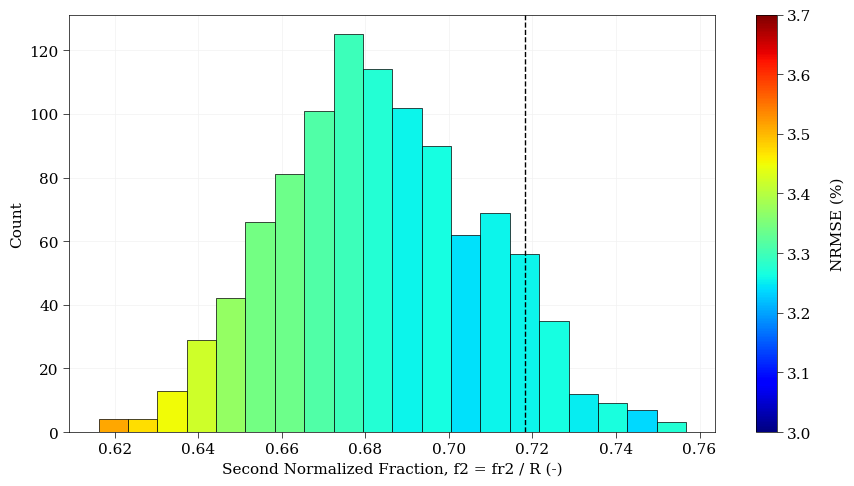

In [40]:
# f2 histogram (f2 = fr2 / R)
bins = 20
xlabel = "Second Normalized Fraction, f2 = fr2 / R (-)"
ylabel = "Count"

fr1 = ensemble["best_fr1"].to_numpy()
fr2 = ensemble["best_fr2"].to_numpy()
R_vals = fr1 + fr2
f2_vals = np.where(R_vals > 0, fr2 / R_vals, np.nan)
j_vals = ensemble["J_m"].to_numpy()

best_idx = ensemble["J_m"].idxmin()
best_R = float(ensemble.loc[best_idx, "best_fr1"] + ensemble.loc[best_idx, "best_fr2"])
best_val = float(ensemble.loc[best_idx, "best_fr2"] / best_R) if best_R > 0 else np.nan

mask_valid = np.isfinite(f1_vals)
mask_valid = np.isfinite(f2_vals)
vals = f2_vals[mask_valid]
j_use = j_vals[mask_valid]

counts, edges = np.histogram(vals, bins=bins)
bin_ids = np.digitize(vals, edges) - 1
bin_ids = np.clip(bin_ids, 0, len(edges) - 2)

bin_medians = np.full(len(edges) - 1, np.nan)
for i in range(len(bin_medians)):
    mask = bin_ids == i
    if np.any(mask):
        bin_medians[i] = np.median(j_use[mask])

cmap = plt.cm.jet
nrmse_pct = bin_medians * 100.0
nrmse_norm = mpl.colors.Normalize(vmin=3.0, vmax=3.7)
colors = [
    cmap(nrmse_norm(v)) if not np.isnan(v) else (0.85, 0.85, 0.85, 1.0)
    for v in nrmse_pct
]

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.bar(edges[:-1], counts, width=np.diff(edges), align="edge", color=colors, edgecolor="black", linewidth=_pt_hair)
if np.isfinite(best_val):
    ax.axvline(best_val, color="black", linestyle="--", linewidth=_pt, zorder=6)

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(axis="both", which="major", direction="out", length=4, width=_pt_hair, colors="black", top=False, right=False)

sm = mpl.cm.ScalarMappable(norm=nrmse_norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("NRMSE (%)", labelpad=14)
cbar.ax.tick_params(width=_pt_hair, length=4)
cbar.outline.set_linewidth(_pt_hair)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

# Uncomment to save as PDF
# fig.savefig(
#     "f2_histogram.pdf",
#     facecolor="white",
#     edgecolor="none",
#     bbox_inches="tight",
#     pad_inches=0.25,
# )

plt.show()

